# Notebook 04 - Visualization Gallery

This lesson starts from Code_Aster-backed result artifacts and sends the same verified result state to every review surface Tuba currently supports.

| Format | Function | Use case |
|---|---|---|
| Interactive PyVista | `plots.plot_deformed_stress()` | Day-to-day notebook review |
| Standalone HTML | `export_html()` | Browser review without Python |
| Semantic scene bundle | `write_scene_bundle()` | Tuba web viewer input |
| TUYAU sub-points | batched radial `tuyau_subpoint_glyphs` field | Pipe-wall review of Code_Aster `SOUS_POINT` stresses |
| Static HTML report | `write_static_report()` | Shareable engineering report |
| PLY | `export_ply()` | Blender with vertex colors |
| glTF | `export_gltf()` | Universal 3D interchange |
| Blender script | `export_blender_script()` | Rebuild the scene in Blender |

Every export below starts from imported Code_Aster result artifacts, not fabricated demo values.


## 1. Setup

Configure imports and the shared notebook visualization backend.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pyvista as pv
# Defaults to zoomable embedded HTML locally; set TUBA_NOTEBOOK_BACKEND=client or static to override.
from tuba.plotting.notebook import configure_notebook_backend
JUPYTER_BACKEND = configure_notebook_backend()

from tuba import Model
from tuba.analysis.code_aster_notebook import configure_code_aster_notebook_runtime, load_or_run_code_aster_results


## 2. Build the Review Model

Build one restrained operating model that all visualization/export cells will reuse.


In [2]:
# ── Build the demo model: L-shaped pipe with vertical riser ────────
#
# Geometry:
#   [0,0,0] ── 3 m straight ── 90° bend (XY) ── 2 m straight
#           ── 90° bend (XZ) ── 2 m vertical riser ── anchor
#
# Supports: anchors at both ends, guide at first bend, rest at second bend.

model = Model("VizGalleryDemo", standard="ASME_B31.3")

model.add_material(
    "Steel",
    E=2.1e11, nu=0.3, rho=7850.0, alpha=1.2e-5,
    allowable_stress={20.0: 137e6, 150.0: 127e6},
)

model.add_pipe_section("DN100", OD=0.1143, WT=0.00602, corrosion_allowance=0.001)

model.define_load_case(
    "Operating",
    gravity=True,
    pressure=1.5e6,
    temperature=150.0,
    ref_temperature=20.0,
)

with model.pipe(section="DN100", material="Steel") as b:
    b.start([0, 0, 0], support="anchor")
    b.run(3.0)
    b.add_support(type="guide")
    b.bend(radius=0.3, angle=90, plane="XY")
    b.run(2.0)
    b.add_support(type="rest")
    b.bend(radius=0.3, angle=90, plane="XZ")
    b.run(2.0)
    b.end(support="anchor")

model.validate()
print(f"Model '{model.project_name}': {len(model.nodes)} nodes, {len(model.elements)} elements")
print(f"Sections: {list(model.sections.keys())}")
print(f"Load cases: {list(model.load_cases.keys())}")

Model 'VizGalleryDemo': 6 nodes, 5 elements
Sections: ['DN100']
Load cases: ['Operating']


## 3. Load or Run Code_Aster Results

The next cell imports existing Code_Aster tables or executes the configured runtime before any result visualization is produced.


In [3]:
CODE_ASTER_RUNTIME = configure_code_aster_notebook_runtime()
# VS Code/Jupyter review defaults to committed real Code_Aster artifacts; set True only after the runtime doctor passes.
RUN_CODE_ASTER = False
CODE_ASTER_WORK_DIR = REPO_ROOT / "notebooks" / "code_aster_results" / "viz_gallery_operating"
VIZ_GALLERY_OUTPUT_DIR = REPO_ROOT / "notebooks"

code_aster_run = load_or_run_code_aster_results(
    model,
    "Operating",
    CODE_ASTER_WORK_DIR,
    run_solver=RUN_CODE_ASTER,
    exec_method=CODE_ASTER_RUNTIME.exec_method,
    wsl_distro=CODE_ASTER_RUNTIME.wsl_distro,
    docker_image=CODE_ASTER_RUNTIME.docker_image,
)
results = code_aster_run.results
code_aster_artifact = code_aster_run.artifact

if code_aster_run.ran_solver:
    print("Code_Aster solver executed for this notebook run.")
print(f"Loaded Code_Aster results from: {CODE_ASTER_WORK_DIR.resolve()}")
print(f"Node result count: {len(results.node_results)}")
print(f"Element result count: {len(results.element_results)}")

tuyau_subpoints = code_aster_artifact.result_state.metadata.get("tuyau_subpoints", [])
print(f"TUYAU sub-point rows: {len(tuyau_subpoints)}")
if tuyau_subpoints:
    first = tuyau_subpoints[0]
    print(f"First TUYAU sub-point position source: {first.get('position_source')}")
    print(f"First TUYAU sub-point shell display position: {first.get('display_position')}")


Loaded Code_Aster results from: D:\Gitprojects\Tuba_v4\notebooks\code_aster_results\viz_gallery_operating
Node result count: 6
Element result count: 5
TUYAU sub-point rows: 24255
First TUYAU sub-point position source: code_aster_tuyau_subpoint_formula
First TUYAU sub-point shell display position: [0.0, 0.0, 0.05113]


---

## 4. Interactive PyVista Rendering

The primary notebook visualization. PyVista renders an inline 3D widget with full
**orbit / pan / zoom** controls directly in the Jupyter cell output.

Available plot functions in `tuba.plotting.plots`:

| Function | What it shows |
|----------|---------------|
| `plot_deformed` | Deformed shape only |
| `plot_stress` | Un-deformed stress contour |
| `plot_deformed_stress` | **Deformed shape + stress colours** (primary view) |
| `plot_displacement_vectors` | Displacement arrows at each node |
| `plot_reactions` | Reaction force arrows at supports |
| `plot_temperature` | Temperature field contour |

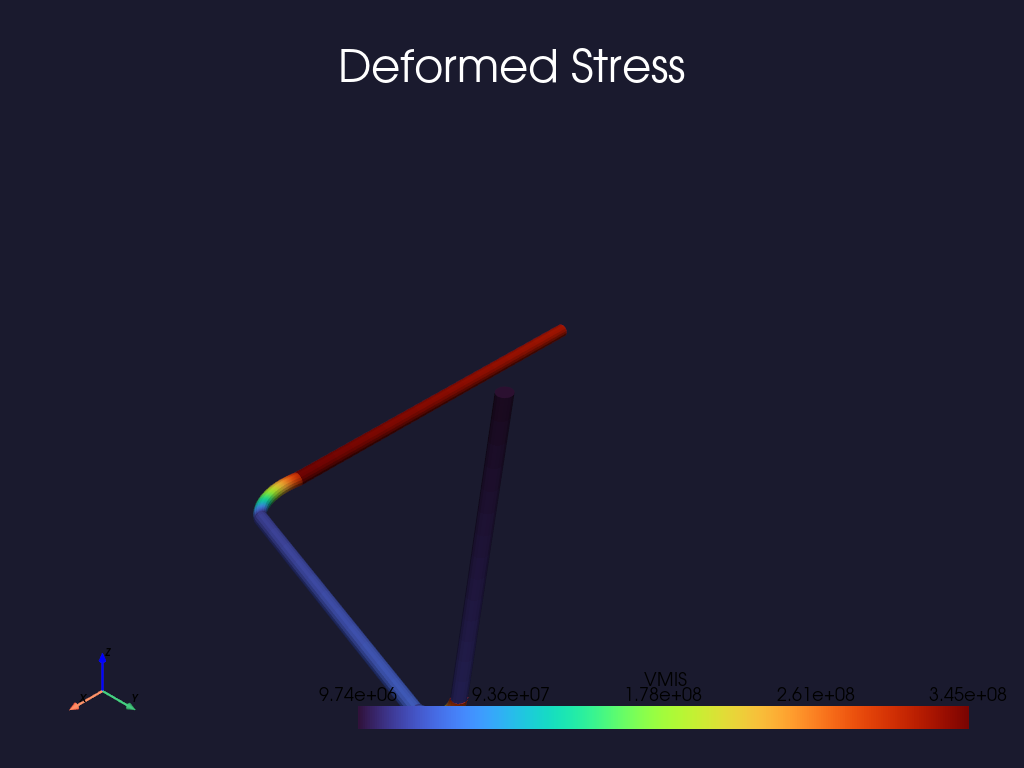

In [4]:
# ── 1. Interactive PyVista — Deformed Stress View ──────────────────
from tuba.plotting import plots

plots.plot_deformed_stress(results, deform_scale=50.0, model=model, jupyter_backend=JUPYTER_BACKEND)

---

## 5. Standalone HTML Export (vtk.js)

Generates a **self-contained HTML file** with an embedded 3D viewer powered by vtk.js.
Share with anyone — **no Python installation required**. The recipient just opens the
`.html` file in any modern browser and gets full interactive 3D.

In [5]:
# ── 2. Standalone HTML Export ──────────────────────────────────────
from IPython.display import IFrame, display
from tuba.plotting.export import export_html

html_path = VIZ_GALLERY_OUTPUT_DIR / "viz_gallery_deformed.html"
export_html(results, html_path, model=model)
print(f"✓ Open {html_path} in your browser for interactive 3D review.")
display(IFrame(src=html_path.name, width="100%", height=720))

✓ Open D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_deformed.html in your browser for interactive 3D review.


---

## 6. Semantic Scene Bundle (Web Viewer)

A directory of **structured JSON files** describing every scene object, overlay, issue,
and route review. This is the native data format consumed by the **Tuba web viewer**
(Three.js front-end).

Bundle structure:
```
viz_gallery_bundle/
├── scene.json              ← master manifest
├── metadata/
│   ├── objects.json         ← all scene objects
│   ├── overlays.json        ← stress overlays, etc.
│   └── issues.json          ← flagged issues
└── geometry/
    └── *.json               ← geometry assets
```

In [6]:
from tuba.analysis import create_operating_geometry_state, create_visual_deformed_geometry_state
from tuba.visualization import (
    build_visualization_scene,
    SceneBuildOptions,
    write_scene_bundle,
)

operating_state = create_operating_geometry_state(model=model, result_state=code_aster_artifact.result_state)
visual_state = create_visual_deformed_geometry_state(
    model=model,
    result_state=code_aster_artifact.result_state,
    visual_scale=50.0,
)
analysis_meshes = [code_aster_artifact.analysis_mesh] if code_aster_artifact.analysis_mesh is not None else []
scene = build_visualization_scene(
    model,
    options=SceneBuildOptions(),
    analysis_meshes=analysis_meshes,
    result_states=[code_aster_artifact.result_state],
    geometry_states=[operating_state, visual_state],
)
bundle = write_scene_bundle(scene, VIZ_GALLERY_OUTPUT_DIR / "viz_gallery_bundle")

print(f"Scene bundle written to: {bundle.root}")
print(f"  scene.json : {bundle.scene_path}")
print(f"  metadata/  : {bundle.metadata_dir}")
print(f"  geometry/  : {bundle.geometry_dir}")

tuyau_subpoint_objects = [obj for obj in scene.objects if obj.kind == "tuyau_subpoint_field"]
tuyau_subpoint_assets = [asset for asset in scene.geometry_assets if asset.format == "tuyau_subpoint_glyphs"]
tuyau_subpoint_overlay = next(
    (overlay for overlay in scene.overlays if overlay.data.get("result_type") == "tuyau_subpoints"),
    None,
)
print(f"TUYAU sub-point field objects: {len(tuyau_subpoint_objects)}")
print(f"TUYAU sub-point batched assets: {len(tuyau_subpoint_assets)}")
if tuyau_subpoint_overlay is not None:
    print(f"TUYAU source file: {tuyau_subpoint_overlay.data.get('source_file')}")
    print(f"TUYAU position source: {tuyau_subpoint_overlay.data.get('position_source')}")


Scene bundle written to: D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_bundle
  scene.json : D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_bundle\scene.json
  metadata/  : D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_bundle\metadata
  geometry/  : D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_bundle\geometry
TUYAU sub-point field objects: 1
TUYAU sub-point batched assets: 1
TUYAU source file: D:\Gitprojects\Tuba_v4\notebooks\code_aster_results\viz_gallery_operating\study_sieq.csv
TUYAU position source: code_aster_tuyau_subpoint_formula


---

## 7. Static HTML Report

A **shareable report folder** with an `index.html` page, issue summary, and all scene
data embedded. Ideal for engineering review hand-off — zip the folder, email it, done.
The recipient gets a fully navigable report without any server.

In [7]:
# ── 4. Static HTML Report ────────────────────────────────────────
from tuba.visualization import write_static_report

report = write_static_report(
    scene,
    VIZ_GALLERY_OUTPUT_DIR / "viz_gallery_report",
    title="Tuba v4 — Stress Analysis Report",
)

print(f"Report index        : {report.index_path}")
print(f"Issue summary       : {report.issue_summary_path}")
print(f"Report manifest     : {report.manifest_path}")

Report index        : D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_report\index.html
Issue summary       : D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_report\issue_summary.json
Report manifest     : D:\Gitprojects\Tuba_v4\notebooks\viz_gallery_report\report_manifest.json


---

## 8. PLY Export (Blender with Vertex Colors)

Exports a 3D mesh in **PLY format** with per-vertex RGB stress colours baked in.
Import directly into Blender — the Von Mises stress gradient is visible immediately
via the **Vertex Color** attribute (no material setup required).

Workflow: `export_ply()` → Blender → *File → Import → PLY* → switch to Material Preview.

In [8]:
# ── 5. PLY Export ────────────────────────────────────────────────
from tuba.plotting.export import export_ply

export_ply(results, VIZ_GALLERY_OUTPUT_DIR / "viz_gallery_stress.ply", model=model, cmap="turbo")
print("✓ PLY file with Von Mises vertex colors exported.")

✓ PLY file with Von Mises vertex colors exported.


---

## 9. glTF Export (Universal 3D)

**glTF is the "JPEG of 3D"** — the most widely supported 3D interchange format.
Import into any 3D viewer, CAD tool, game engine, or web application.

Supported viewers: VS Code (glTF Tools), Windows 3D Viewer, Three.js, Babylon.js,
Blender, Unity, Unreal Engine, and more.

In [9]:
# ── 6. glTF Export ───────────────────────────────────────────────
from tuba.plotting.export import export_gltf

export_gltf(results, VIZ_GALLERY_OUTPUT_DIR / "viz_gallery_model.gltf", model=model)
print("✓ glTF model exported for universal 3D viewing.")

✓ glTF model exported for universal 3D viewing.


---

## 10. Blender Python Script

Generates a complete **Blender Python script** that recreates the pipe geometry
with stress-coloured materials from scratch. Run it headless or inside the Blender UI:

```bash
# Headless
blender --background --python viz_gallery_blender.py

# Inside Blender
# Scripting workspace → Open → viz_gallery_blender.py → Run Script
```

The script creates curve objects with bevel for each pipe element and assigns
per-vertex Von Mises stress as vertex colours.

In [10]:
# ── 7. Blender Python Script ─────────────────────────────────────
from tuba.plotting.export import export_blender_script

export_blender_script(results, VIZ_GALLERY_OUTPUT_DIR / "viz_gallery_blender.py", model=model)
print("✓ Blender script generated. Run inside Blender: File → Run Script")

✓ Blender script generated. Run inside Blender: File → Run Script


## Summary

| Format | File type | Use case | Interactivity |
|---|---|---|---|
| PyVista | Notebook output | Day-to-day engineering review | Orbit, pan, zoom |
| HTML export | `.html` | Share with non-Python colleagues | Browser 3D |
| Scene bundle | JSON directory | Feed the Tuba web viewer | Web-viewer dependent |
| Static report | HTML folder | Engineering review handoff | Report plus embedded scene |
| PLY | `.ply` | Blender rendering or animation | Vertex-color stress map |
| glTF | `.gltf` / `.glb` | Universal 3D interchange | Viewer dependent |
| Blender script | `.py` | Full Blender scene automation | Blender dependent |

All formats start from the same Code_Aster `FEAResults` and `Model` objects. The scene bundle also includes one batched radial TUYAU sub-point field on the pipe wall when the imported `study_sieq.csv` contains Code_Aster `SOUS_POINT` rows.

Next: `05_autorouting.ipynb` generates route candidates and Code_Aster study handoff files.
